# L1_m9 feedback variants: full-sky tSZ power spectra

Compute $D_\ell$ from the yang26-rotated Compton-$y$ maps in
`/rds/rds-lxu/flamingo/L1_m9/maps/` for each feedback prescription.

**Part 1 — `anafast` (notebook 05):** subtract the monopole, `healpy.anafast`, deconvolve
the pixel window function, and apply the $f_{\rm sky}$ correction.
Cached: `data/nb35_l1_m9_feedback_tsz_ps.npz` (`scripts/export_L1_m9_feedback_tsz_ps.py`).

**Part 2 — NaMaster bandpowers (feedback comparison):** full-sky and masked $q$-cut spectra
for all nine prescriptions (`scripts/compute_masked_tsz_ps_L1_m9_feedback.py`).
Cached: `data/bandpowers_L1_m9_feedback/masked_tsz_ps.npz`.

In [1]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

REPO = Path("/scratch/scratch-lxu/flamingo_repo")
MAP_DIR = Path("/rds/rds-lxu/flamingo/L1_m9/maps")
DATA_NPZ = REPO / "data/nb35_l1_m9_feedback_tsz_ps.npz"
MASKED_NPZ = REPO / "data/bandpowers_L1_m9_feedback/masked_tsz_ps.npz"
THEORY_NPZ = REPO / "data/theory_masked_tsz_ps_B135.npz"
FIG_DIR = REPO / "figures/nb35_l1_m9_feedback_tsz_ps"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ELL_MIN_NMT = 100
LMAX = 6000
ELL_MIN = 10
NBIN = 40
RECOMPUTE = False

VARIANTS = [
    "L1_m9",
    "fgas+2sigma",
    "fgas-2sigma",
    "fgas-4sigma",
    "fgas-8sigma",
    "Mstar-1sigma",
    "Mstar-1sigma_fgas-4sigma",
    "Jet",
    "Jet_fgas-4sigma",
]

LABELS = {
    "L1_m9": "fiducial (L1_m9)",
    "fgas+2sigma": "fgas +2$\\sigma$",
    "fgas-2sigma": "fgas $-$2$\\sigma$",
    "fgas-4sigma": "fgas $-$4$\\sigma$",
    "fgas-8sigma": "fgas $-$8$\\sigma$",
    "Mstar-1sigma": "M$_*$ $-$1$\\sigma$",
    "Mstar-1sigma_fgas-4sigma": "M$_*$ $-$1$\\sigma$, fgas $-$4$\\sigma$",
    "Jet": "Jet",
    "Jet_fgas-4sigma": "Jet + fgas $-$4$\\sigma$",
}

In [2]:
def map_path(variant: str) -> Path:
    return MAP_DIR / f"y_unlensed_{variant}_lc0_nside4096.fits"


def full_sky_dl(ymap: np.ndarray, *, lmax: int = LMAX) -> tuple[np.ndarray, np.ndarray, float]:
    """Full-sky D_ell with monopole subtracted (notebook 05 convention)."""
    nside = hp.npix2nside(ymap.size)
    f_sky = float(np.mean(ymap != 0.0))
    monopole = float(ymap.mean())
    y_nomono = ymap - monopole
    cl = hp.anafast(y_nomono, lmax=lmax)
    ell = np.arange(cl.size)
    pw = hp.pixwin(nside, lmax=lmax)
    cl = cl / (pw**2 * f_sky)
    dl = ell * (ell + 1) / (2 * np.pi) * cl
    return ell, dl, monopole


def log_bin(ell: np.ndarray, dl: np.ndarray, *, lmin: int = ELL_MIN, lmax: int = LMAX, nbin: int = 40):
    edges = np.logspace(np.log10(lmin), np.log10(lmax), nbin + 1)
    idx = np.digitize(ell, edges) - 1
    lb, db = [], []
    for b in range(nbin):
        sel = (idx == b) & (ell >= lmin)
        if sel.any():
            lb.append(ell[sel].mean())
            db.append(dl[sel].mean())
    return np.array(lb), np.array(db)

In [3]:
def save_spectra_npz(spectra: dict[str, dict]) -> None:
    variants = list(spectra.keys())
    DATA_NPZ.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        DATA_NPZ,
        variants=np.array(variants),
        ell=spectra[variants[0]]["ell"],
        dl=np.stack([spectra[v]["dl"] for v in variants], axis=0),
        ell_b=np.stack([spectra[v]["ell_b"] for v in variants], axis=0),
        dl_b=np.stack([spectra[v]["dl_b"] for v in variants], axis=0),
        monopole=np.array([spectra[v]["monopole"] for v in variants]),
        lmax=LMAX,
        ell_min=ELL_MIN,
        nbin=NBIN,
        map_dir=str(MAP_DIR),
    )
    print(f"saved {DATA_NPZ}")


def load_spectra_npz() -> dict[str, dict]:
    data = np.load(DATA_NPZ, allow_pickle=True)
    variants = list(data["variants"])
    spectra = {}
    for i, variant in enumerate(variants):
        spectra[str(variant)] = {
            "ell": data["ell"],
            "dl": data["dl"][i],
            "ell_b": data["ell_b"][i],
            "dl_b": data["dl_b"][i],
            "monopole": float(data["monopole"][i]),
        }
    return spectra


if DATA_NPZ.exists() and not RECOMPUTE:
    print(f"loading cached spectra from {DATA_NPZ}")
    spectra = load_spectra_npz()
else:
    spectra = {}
    for variant in VARIANTS:
        path = map_path(variant)
        if not path.exists():
            print(f"skip {variant}: missing {path}")
            continue
        print(f"loading {path.name} ...", flush=True)
        ymap = hp.read_map(path, verbose=False)
        ell, dl, monopole = full_sky_dl(ymap)
        ell_b, dl_b = log_bin(ell, dl, nbin=NBIN)
        spectra[variant] = {
            "ell": ell, "dl": dl, "ell_b": ell_b, "dl_b": dl_b, "monopole": monopole,
        }
        print(
            f"  {variant}: monopole={monopole:.4e}, "
            f"D_ell(l~3000)={float(np.interp(3000, ell, dl)):.4e}",
            flush=True,
        )
    save_spectra_npz(spectra)

print(f"ready: {len(spectra)} spectra")

loading cached spectra from /scratch/scratch-lxu/flamingo_repo/data/nb35_l1_m9_feedback_tsz_ps.npz
ready: 9 spectra


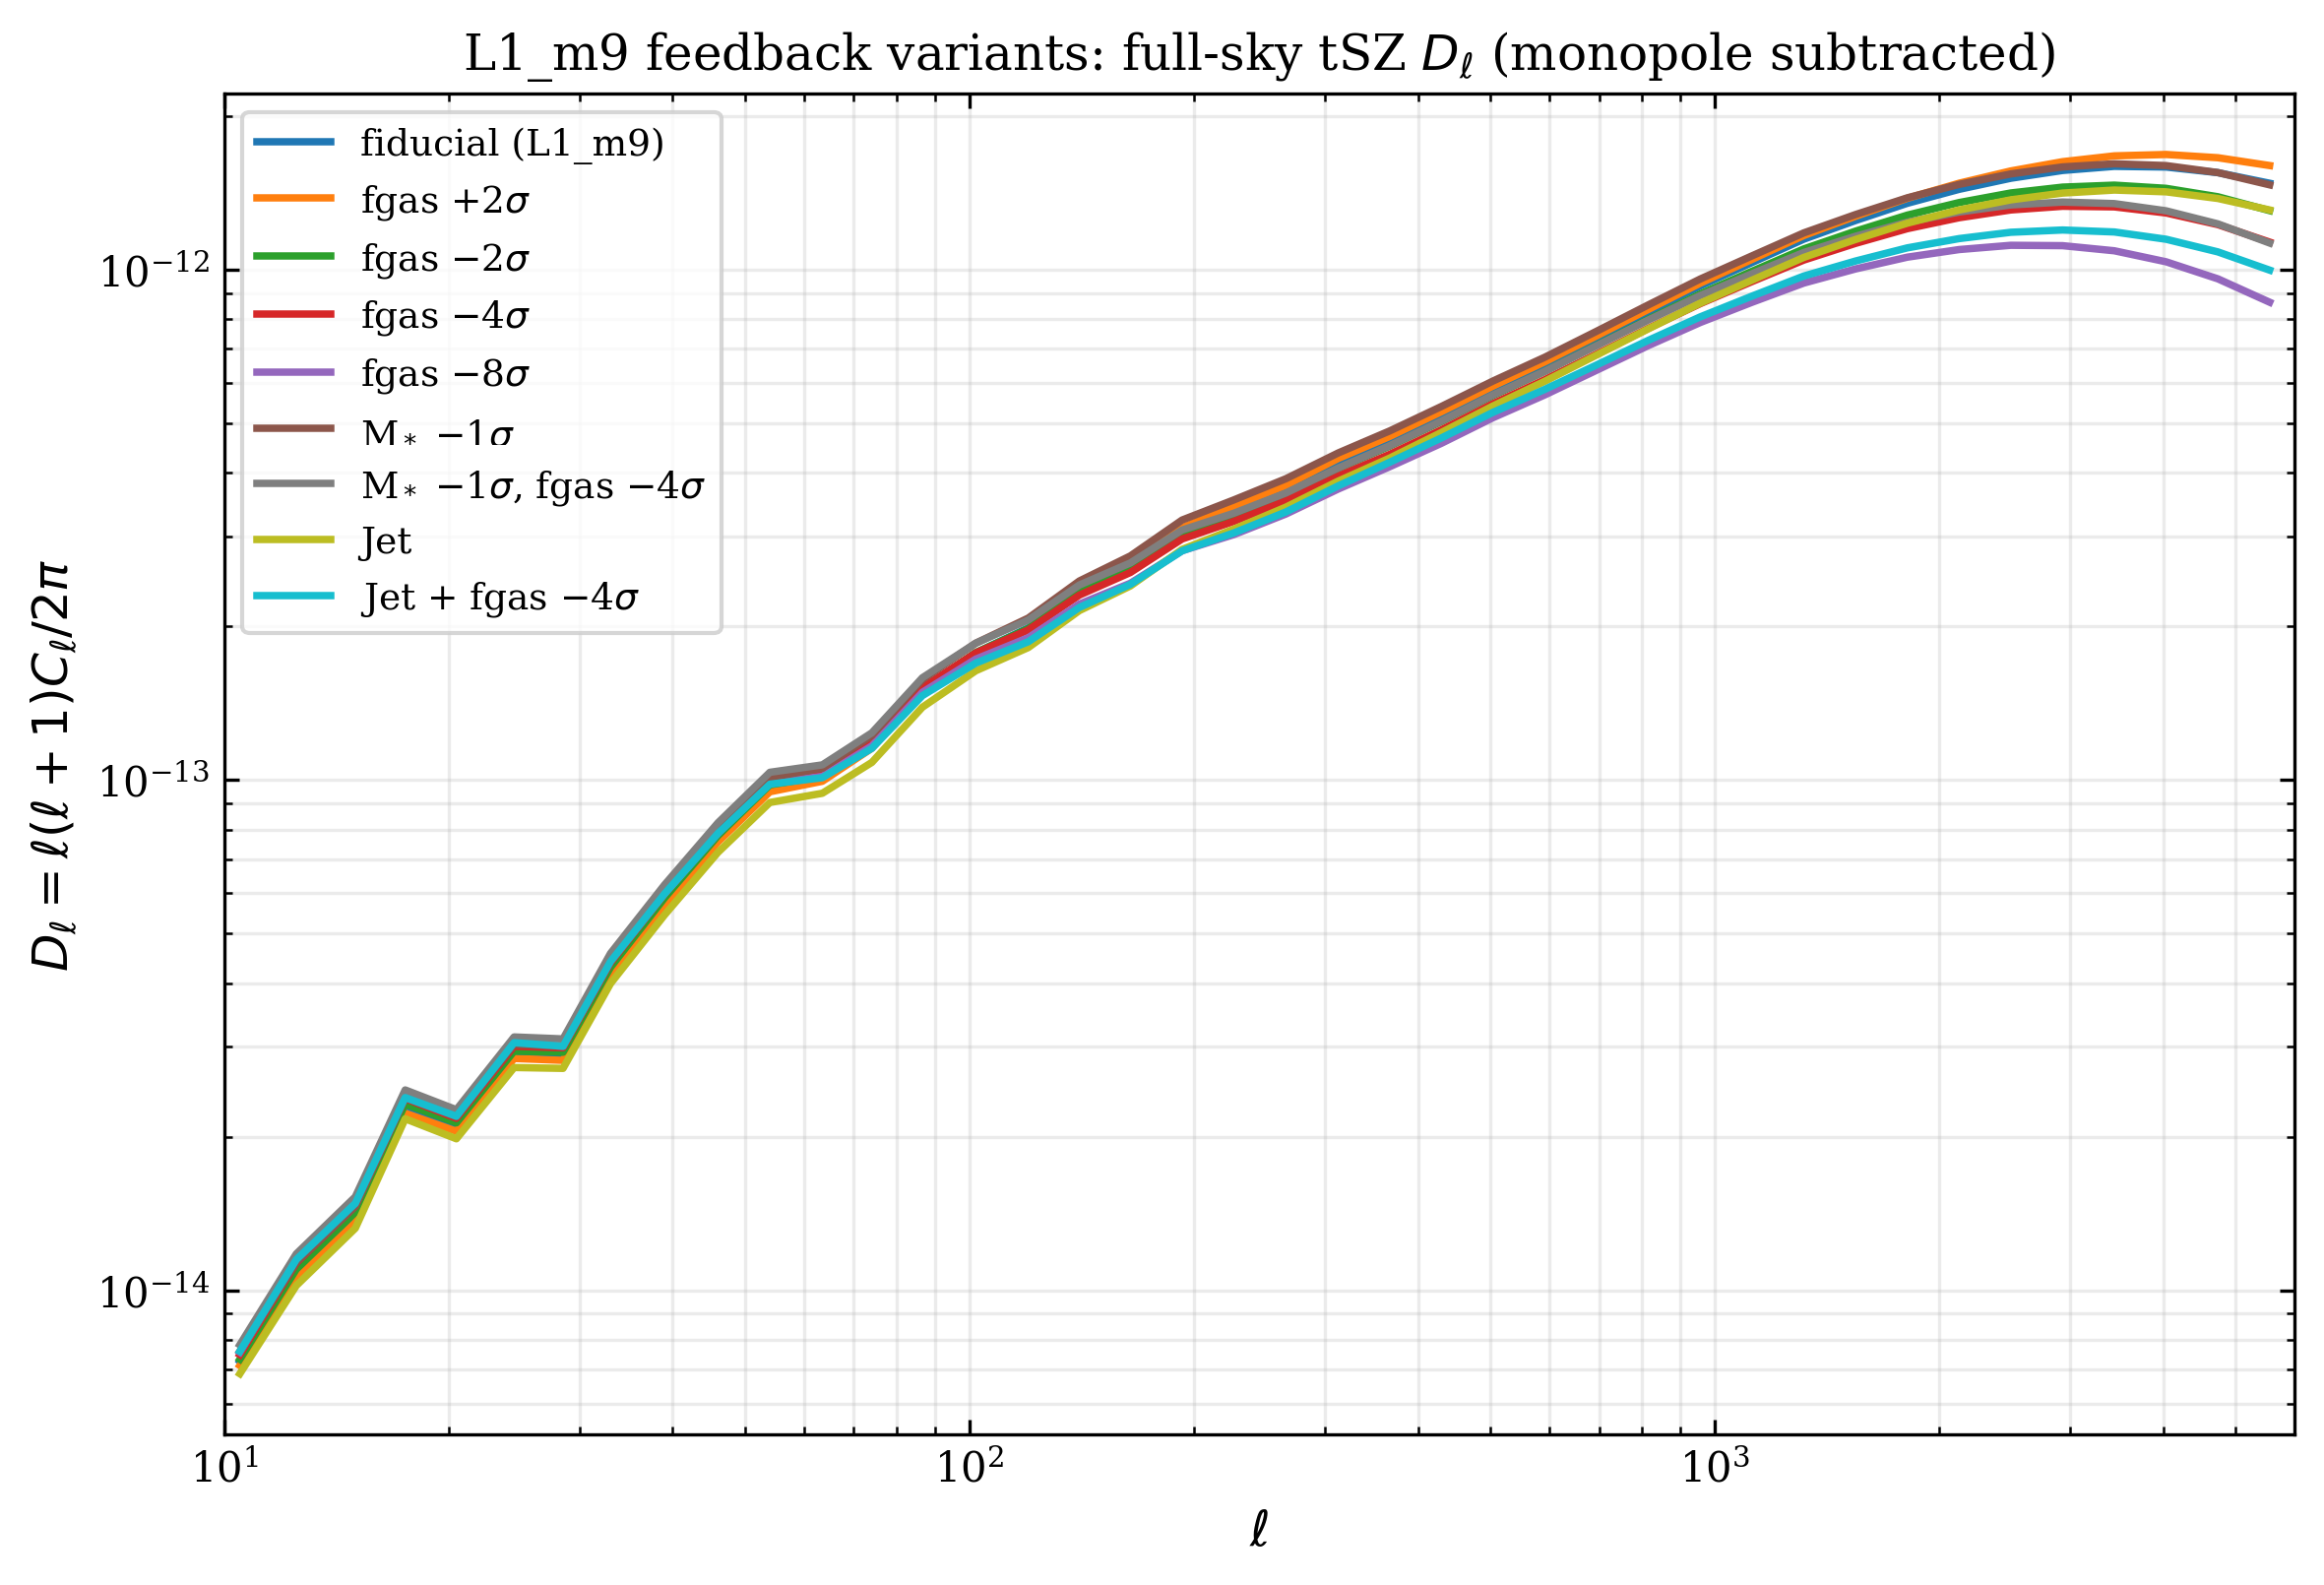

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = plt.cm.tab10(np.linspace(0, 0.95, len(spectra)))

for color, variant in zip(colors, spectra):
    d = spectra[variant]
    ax.loglog(
        d["ell_b"], d["dl_b"], "-", lw=1.8, color=color,
        label=LABELS.get(variant, variant),
    )

ax.set_xlim(ELL_MIN, LMAX)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$")
ax.set_title(r"L1_m9 feedback variants: full-sky tSZ $D_\ell$ (monopole subtracted)")
ax.legend(loc="upper left", ncol=1, frameon=True)
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
plt.show()

## Part 2: NaMaster bandpowers — all feedback prescriptions

Rebuild maps: `python scripts/compute_masked_tsz_ps_L1_m9_feedback.py`  
Rebuild theory: `python scripts/export_masked_tsz_theory_B135.py`

hmfast theory overlays:
- **B=1.0 A10** (grey dash-dot): flamingo `D3A_COSMOLOGY`, Arnaud A10 GNFW (`P0=8.403`, ...), notebook 09 manual SNR completeness — matches L2p8 fiducial in nb05/09.
- **B=1.35** (black dashed): parametric SNR matching `q_from_mz` catalogue cuts.

### Full sky
All nine variants on one plot, plus ratio to fiducial L1_m9.

### Masked SNR cuts
For each $q$ threshold: all variants on the same axes (and ratio panels).

In [5]:
bp = np.load(MASKED_NPZ, allow_pickle=True)
bp_variants = [str(v) for v in bp["variants"]]
ellb_nmt = bp["ellb"]
dl_full_nmt = bp["dl_fullsky"]
dl_masked = bp["dl_masked"]  # (n_variant, n_cut, n_bin); cuts: q50, q20, q10, q5, q3, q1
n_det = bp["n_detected"]
q_cuts = bp["q_cuts"]

th = np.load(THEORY_NPZ)
dl_th_full = th["dl_fullsky_b135"]
dl_th_masked = th["dl_masked_b135"]
dl_th_full_b1 = th["dl_fullsky_b1"]
dl_th_masked_b1 = th["dl_masked_b1"]
TH_LABEL_B135 = r"hmfast ($B=1.35$)"
TH_LABEL_B1 = r"hmfast ($B=1.0$, A10)"

Q_CUTS = [
    (0, "qgt50", r"$q > 50$"),
    (1, "qgt20", r"$q > 20$"),
    (2, "qgt10", r"$q > 10$"),
    (3, "qgt5", r"$q > 5$"),
    (4, "qgt3", r"$q > 3$"),
    (5, "qgt1", r"$q > 1$"),
]

sel_nmt = ellb_nmt >= ELL_MIN_NMT
ell_nmt = ellb_nmt[sel_nmt]

print(f"loaded {MASKED_NPZ.name}: {len(bp_variants)} variants, {sel_nmt.sum()} bins with ell >= {ELL_MIN_NMT}")
print(f"loaded theory {THEORY_NPZ.name}  A_SZ={float(th['A_SZ']):.6f}  B={float(th['B'])}")
for ic, (_, tag, title) in enumerate(Q_CUTS):
    print(f"  {title}: N(q>{int(q_cuts[ic])}) = {dict(zip(bp_variants, n_det[:, ic]))}")

loaded masked_tsz_ps.npz: 9 variants, 196 bins with ell >= 100
loaded theory theory_masked_tsz_ps_B135.npz  A_SZ=-4.051178  B=1.35
  $q > 50$: N(q>50) = {'L1_m9': np.int64(4), 'fgas+2sigma': np.int64(3), 'fgas-2sigma': np.int64(5), 'fgas-4sigma': np.int64(4), 'fgas-8sigma': np.int64(3), 'Mstar-1sigma': np.int64(4), 'Mstar-1sigma_fgas-4sigma': np.int64(4), 'Jet': np.int64(4), 'Jet_fgas-4sigma': np.int64(2)}
  $q > 20$: N(q>20) = {'L1_m9': np.int64(49), 'fgas+2sigma': np.int64(34), 'fgas-2sigma': np.int64(39), 'fgas-4sigma': np.int64(38), 'fgas-8sigma': np.int64(35), 'Mstar-1sigma': np.int64(39), 'Mstar-1sigma_fgas-4sigma': np.int64(34), 'Jet': np.int64(35), 'Jet_fgas-4sigma': np.int64(36)}
  $q > 10$: N(q>10) = {'L1_m9': np.int64(217), 'fgas+2sigma': np.int64(235), 'fgas-2sigma': np.int64(220), 'fgas-4sigma': np.int64(206), 'fgas-8sigma': np.int64(200), 'Mstar-1sigma': np.int64(220), 'Mstar-1sigma_fgas-4sigma': np.int64(217), 'Jet': np.int64(232), 'Jet_fgas-4sigma': np.int64(197)}
  $q 

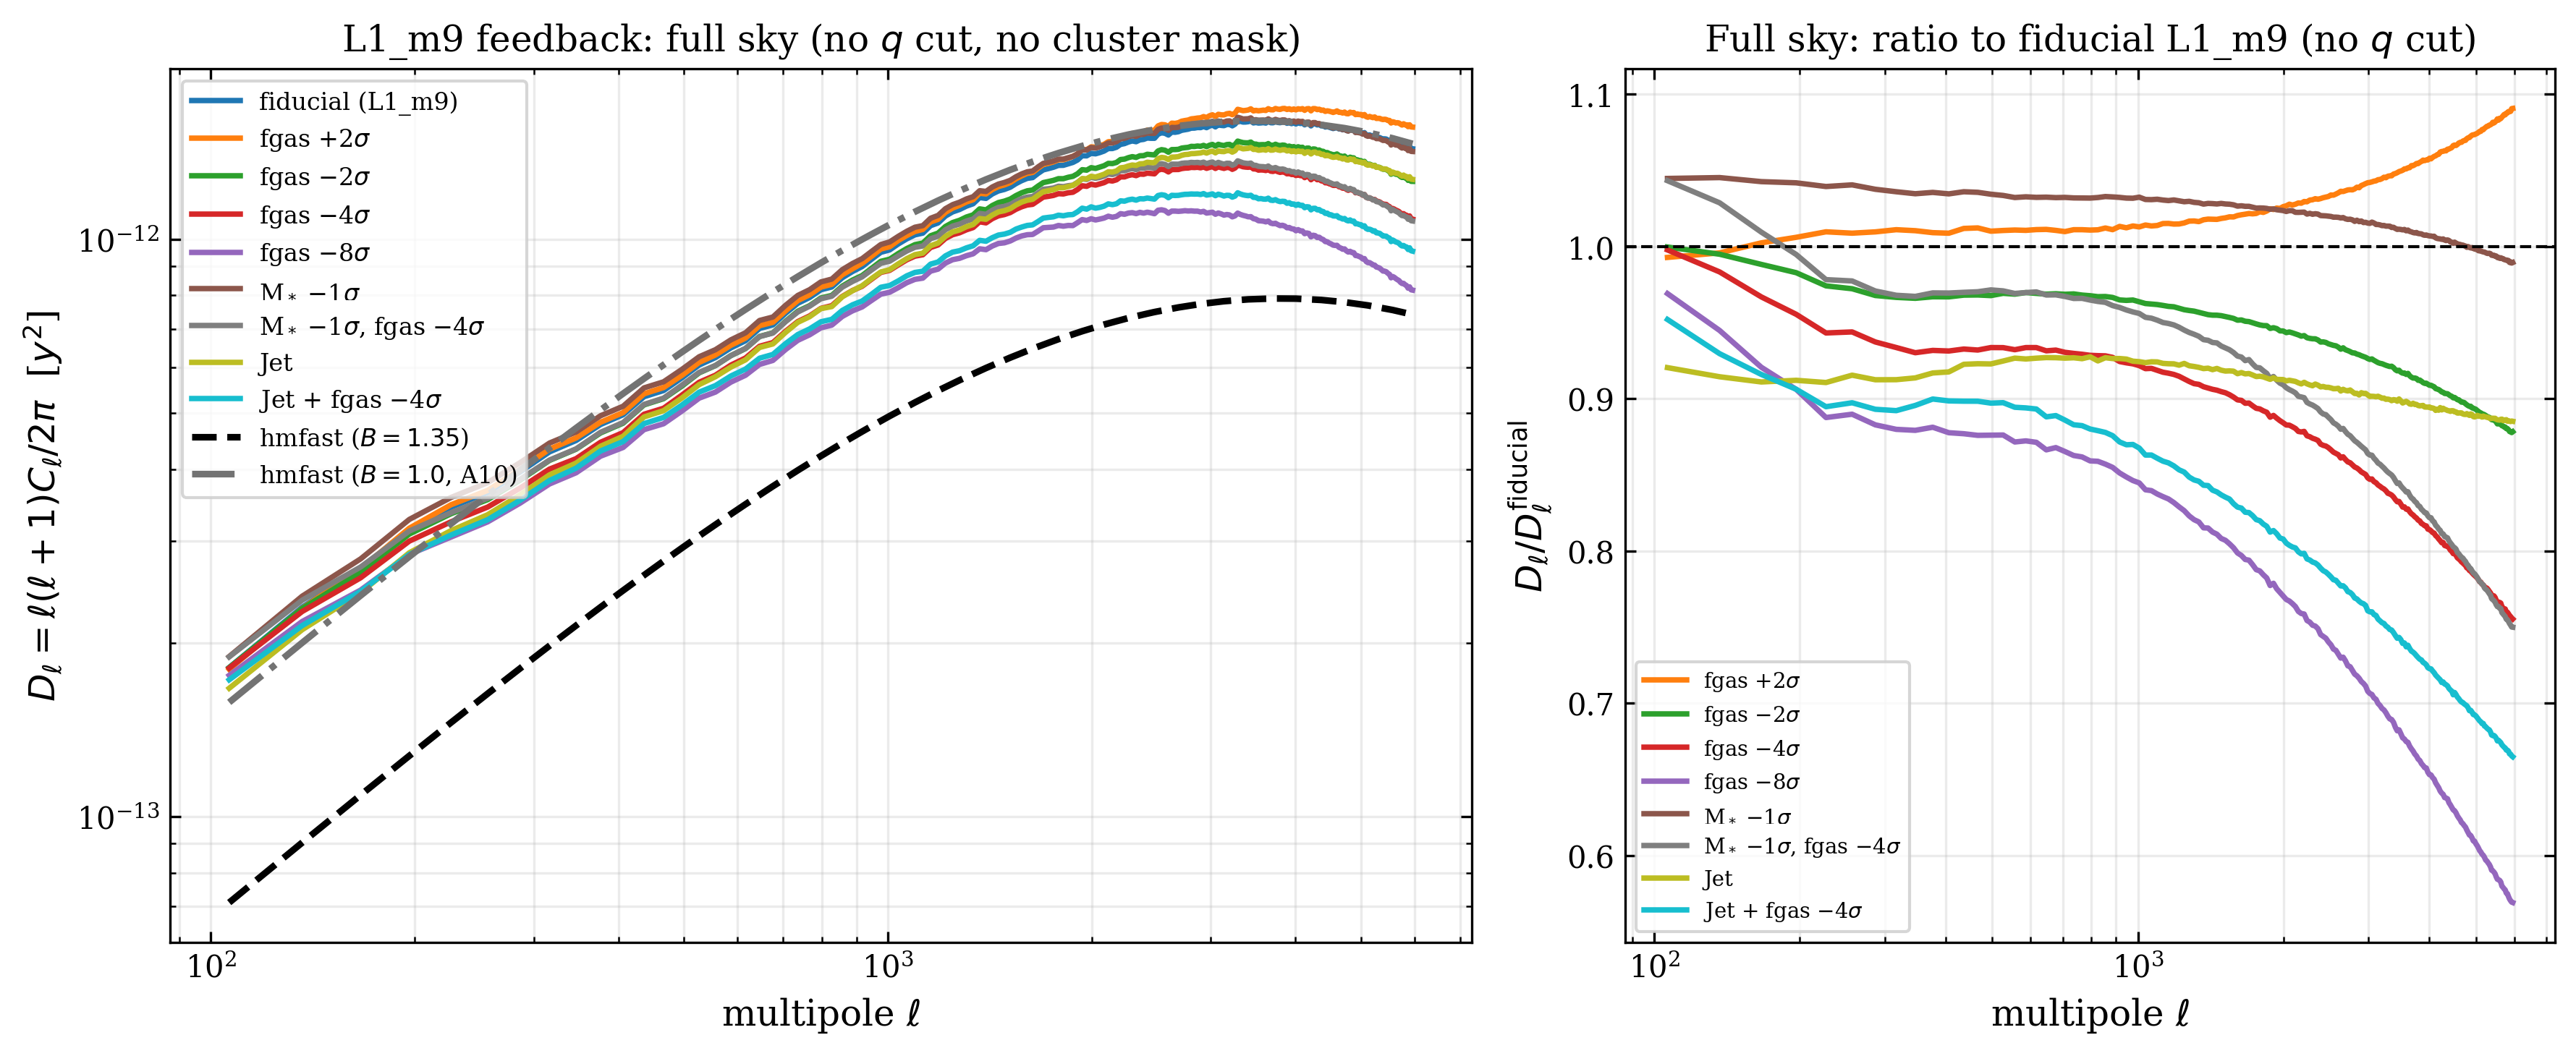

In [6]:
colors = plt.cm.tab10(np.linspace(0, 0.95, len(bp_variants)))
fid_idx = bp_variants.index("L1_m9")
dl_fid = dl_full_nmt[fid_idx, sel_nmt]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.4, 1]})

ax = axes[0]
for color, variant in zip(colors, bp_variants):
    iv = bp_variants.index(variant)
    ax.loglog(ell_nmt, dl_full_nmt[iv, sel_nmt], lw=1.8, color=color, label=LABELS.get(variant, variant))
ax.loglog(ell_nmt, dl_th_full[sel_nmt], "k--", lw=2.2, label=TH_LABEL_B135)
ax.loglog(ell_nmt, dl_th_full_b1[sel_nmt], color="0.45", ls="-.", lw=2.2, label=TH_LABEL_B1)
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$  [$y^2$]")
ax.set_title(r"L1_m9 feedback: full sky (no $q$ cut, no cluster mask)")
ax.legend(loc="upper left", fontsize=8, frameon=True)
ax.grid(True, which="both", alpha=0.25)

ax = axes[1]
for color, variant in zip(colors, bp_variants):
    if variant == "L1_m9":
        continue
    iv = bp_variants.index(variant)
    ax.semilogx(ell_nmt, dl_full_nmt[iv, sel_nmt] / dl_fid, lw=1.8, color=color, label=LABELS.get(variant, variant))
ax.axhline(1.0, color="k", ls="--", lw=1)
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(r"$D_\ell / D_\ell^{\rm fiducial}$")
ax.set_title(r"Full sky: ratio to fiducial L1_m9 (no $q$ cut)")
ax.legend(loc="best", fontsize=7, frameon=True)
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"l1_feedback_fullsky_namaster.{ext}")
plt.show()

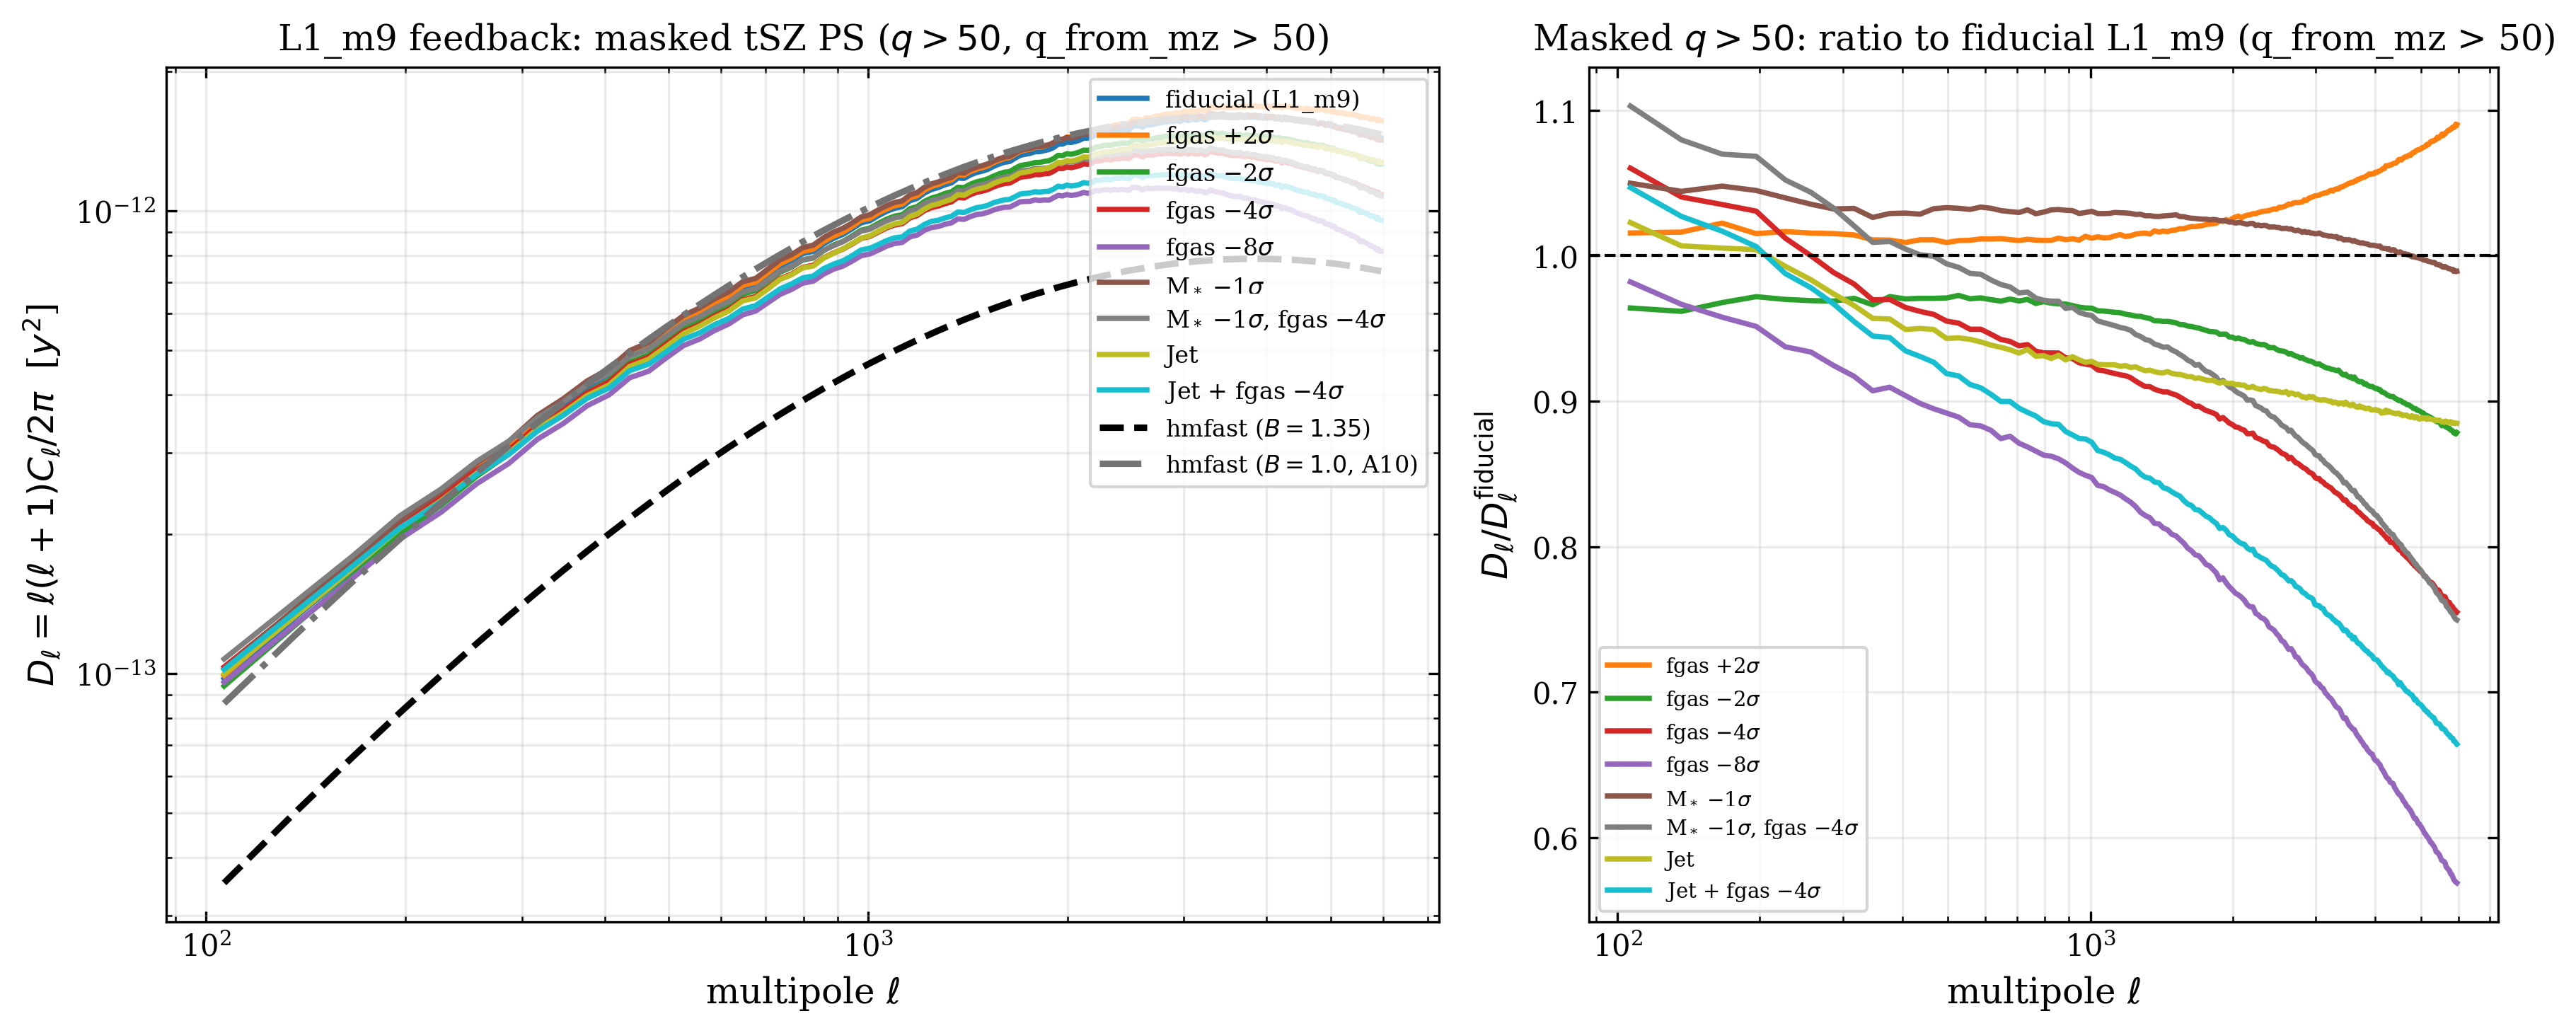

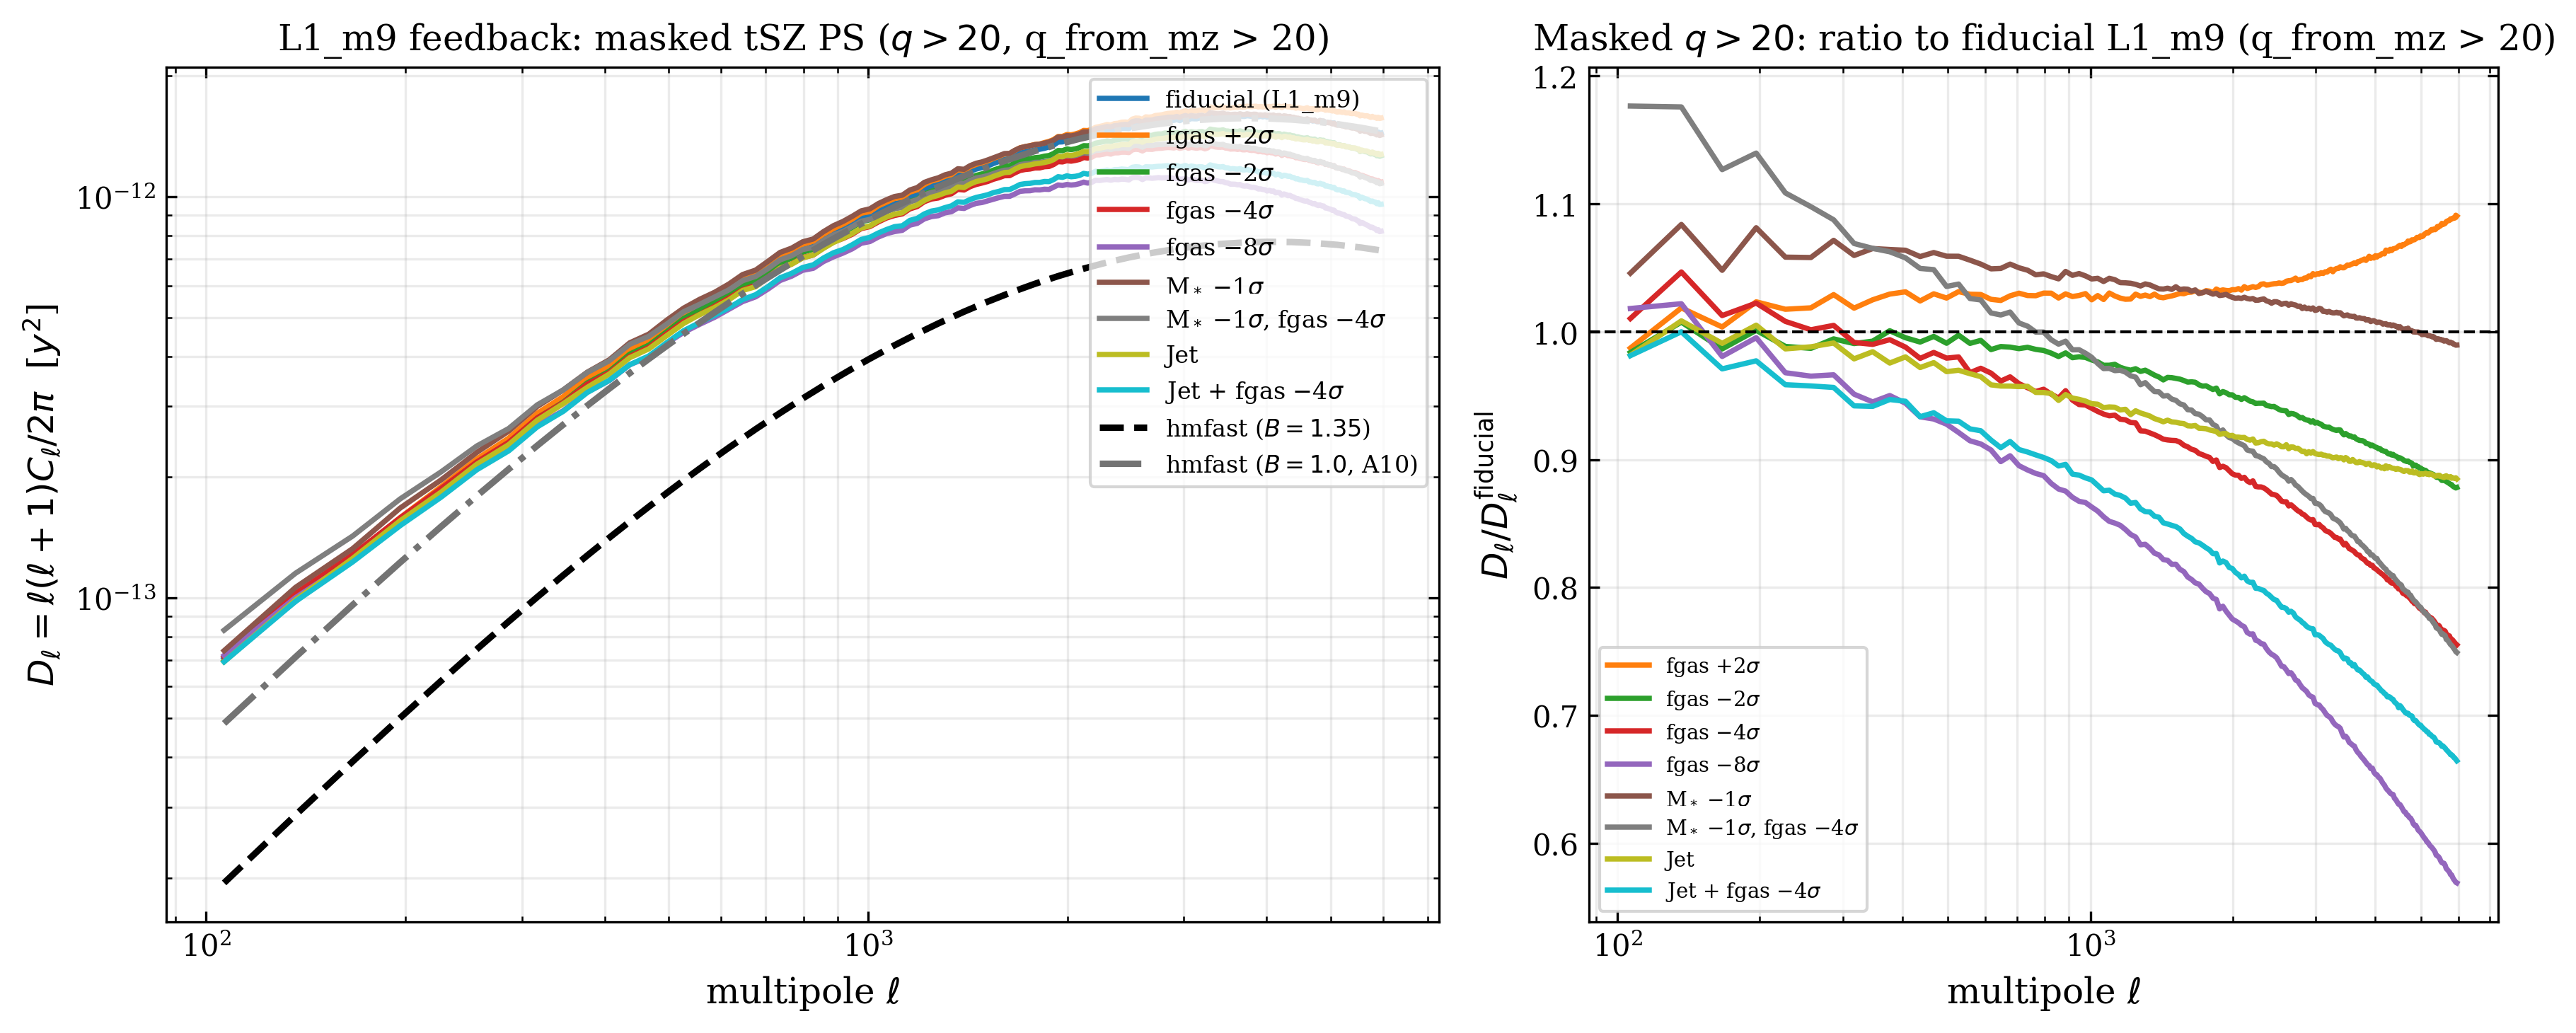

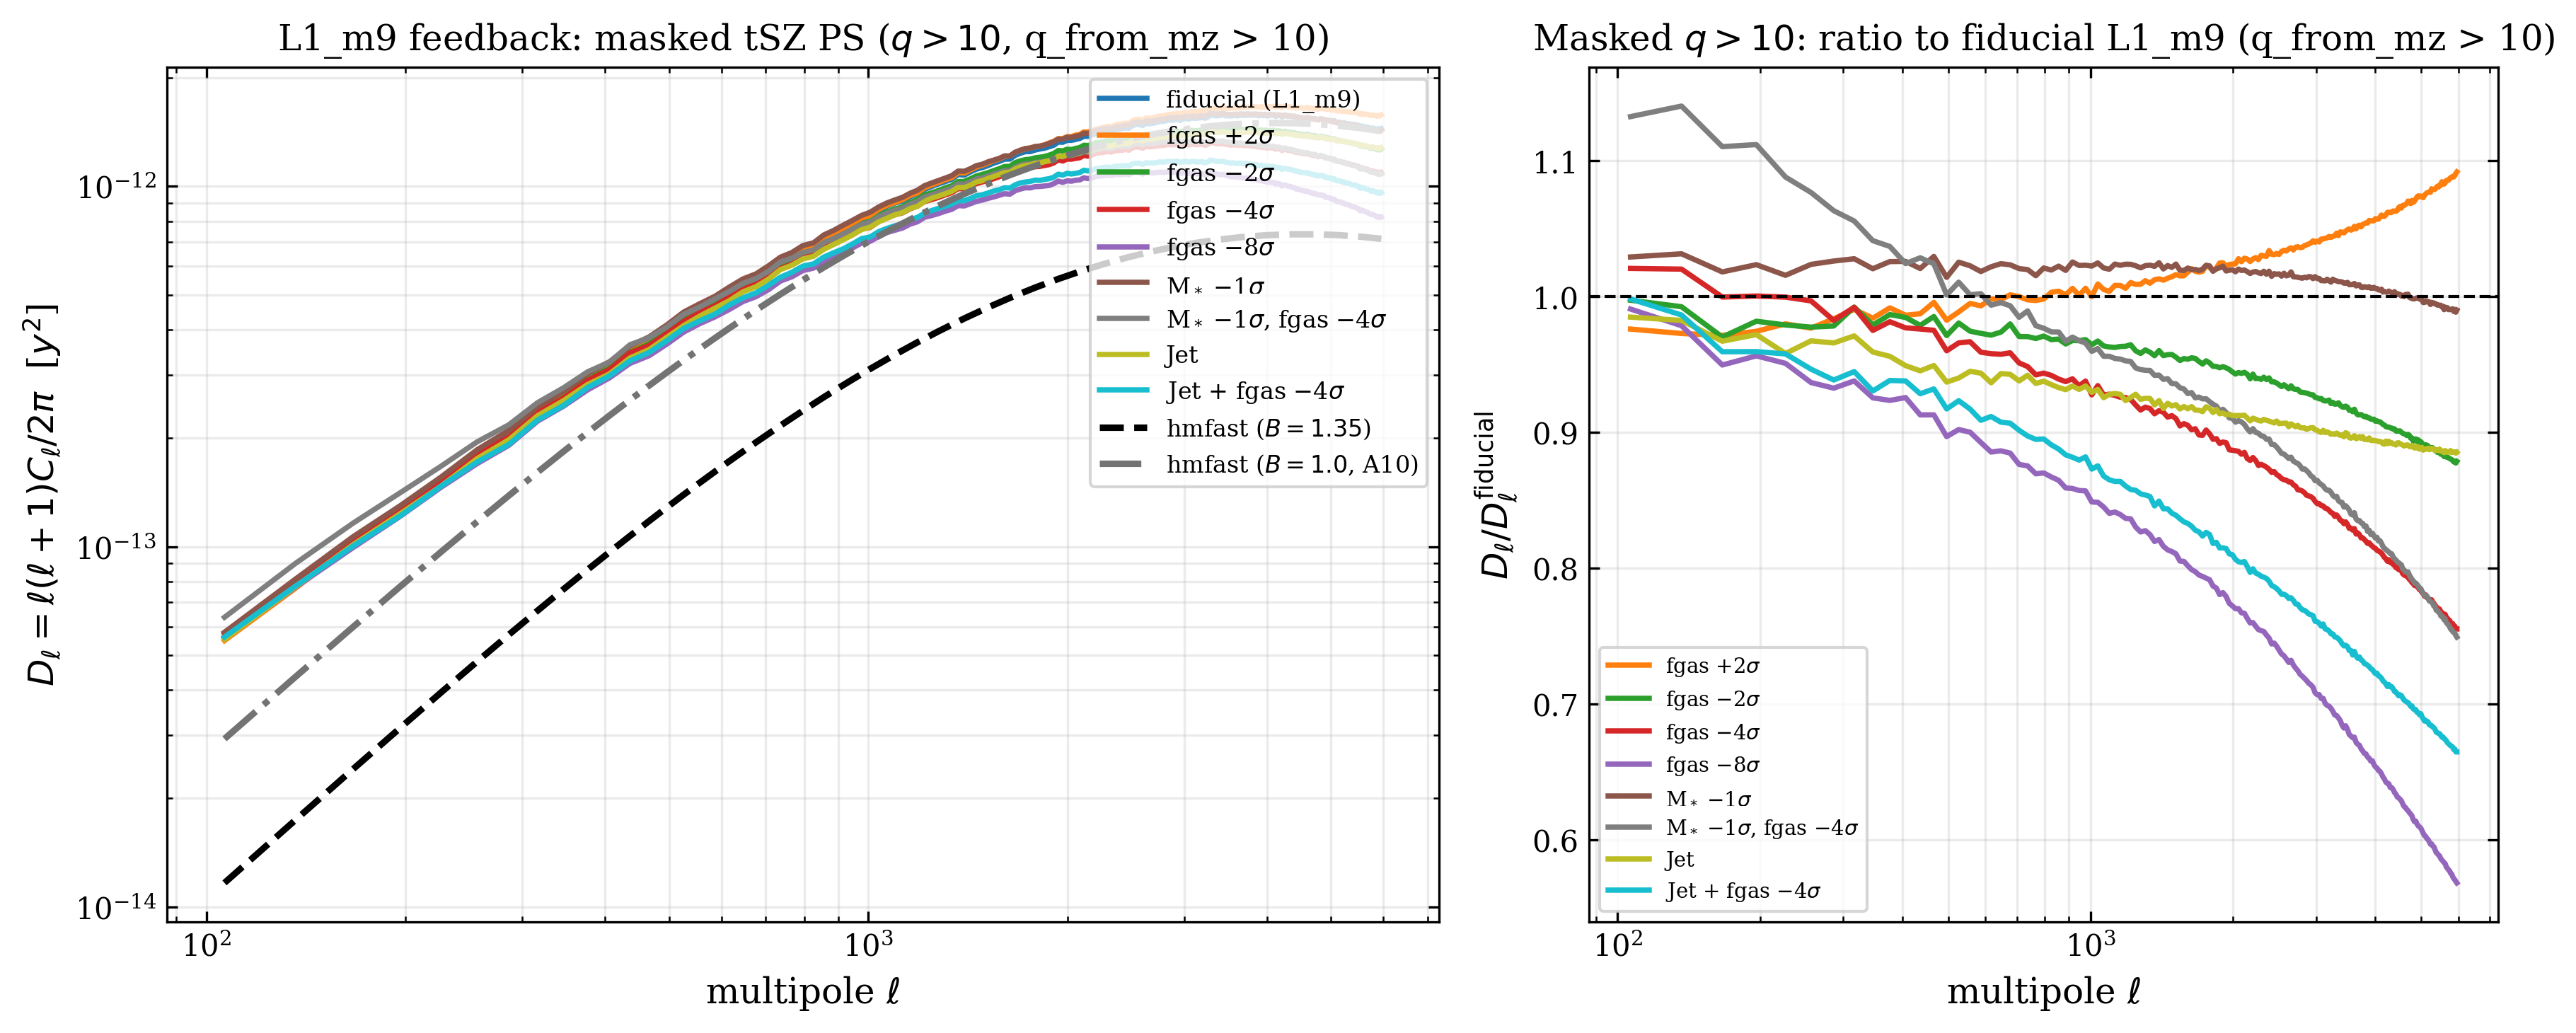

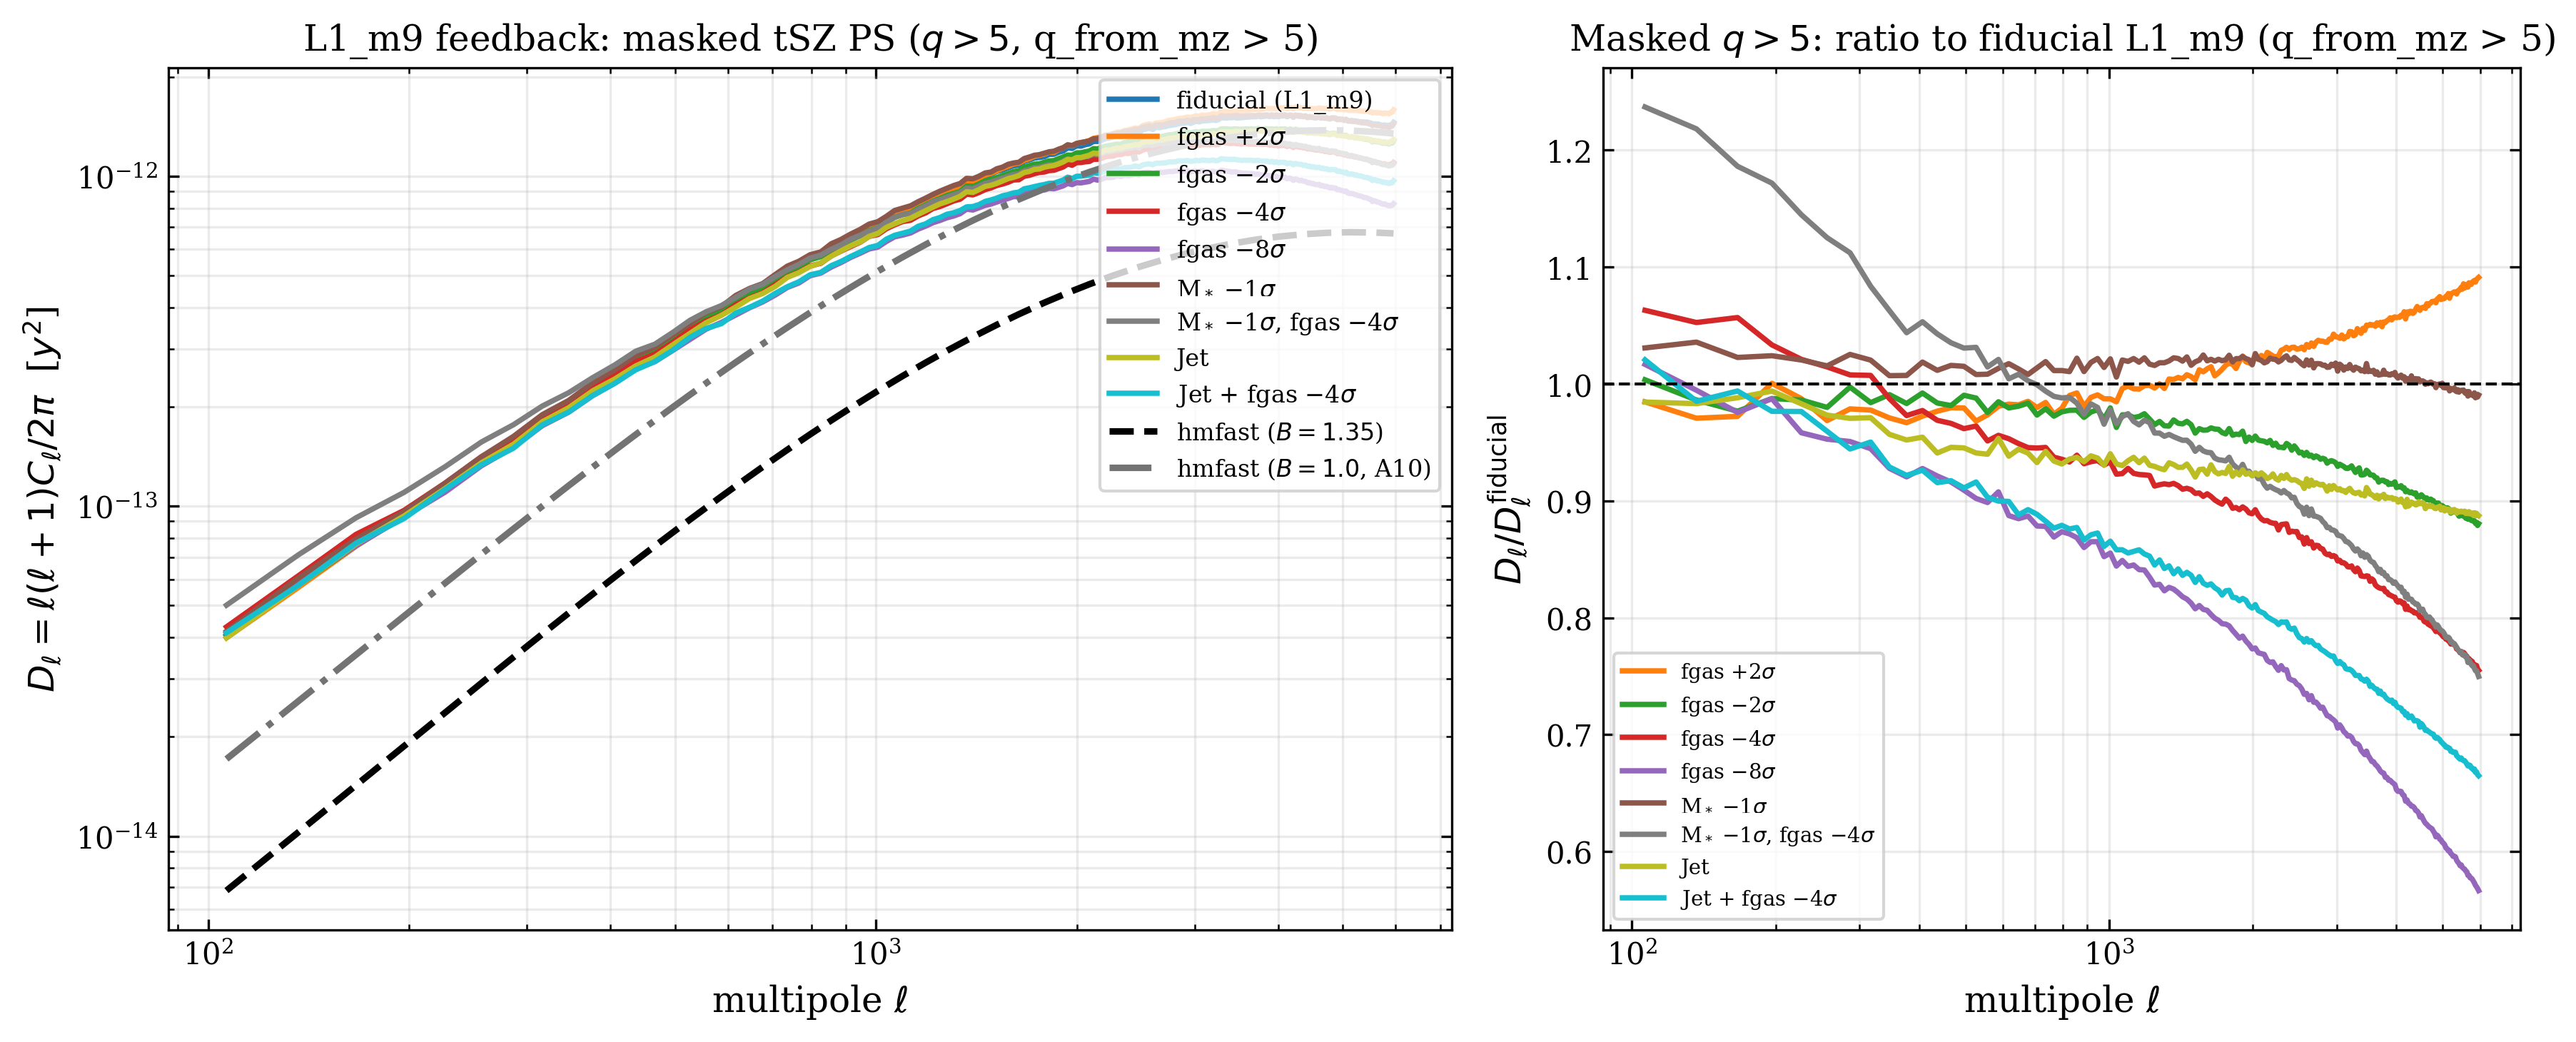

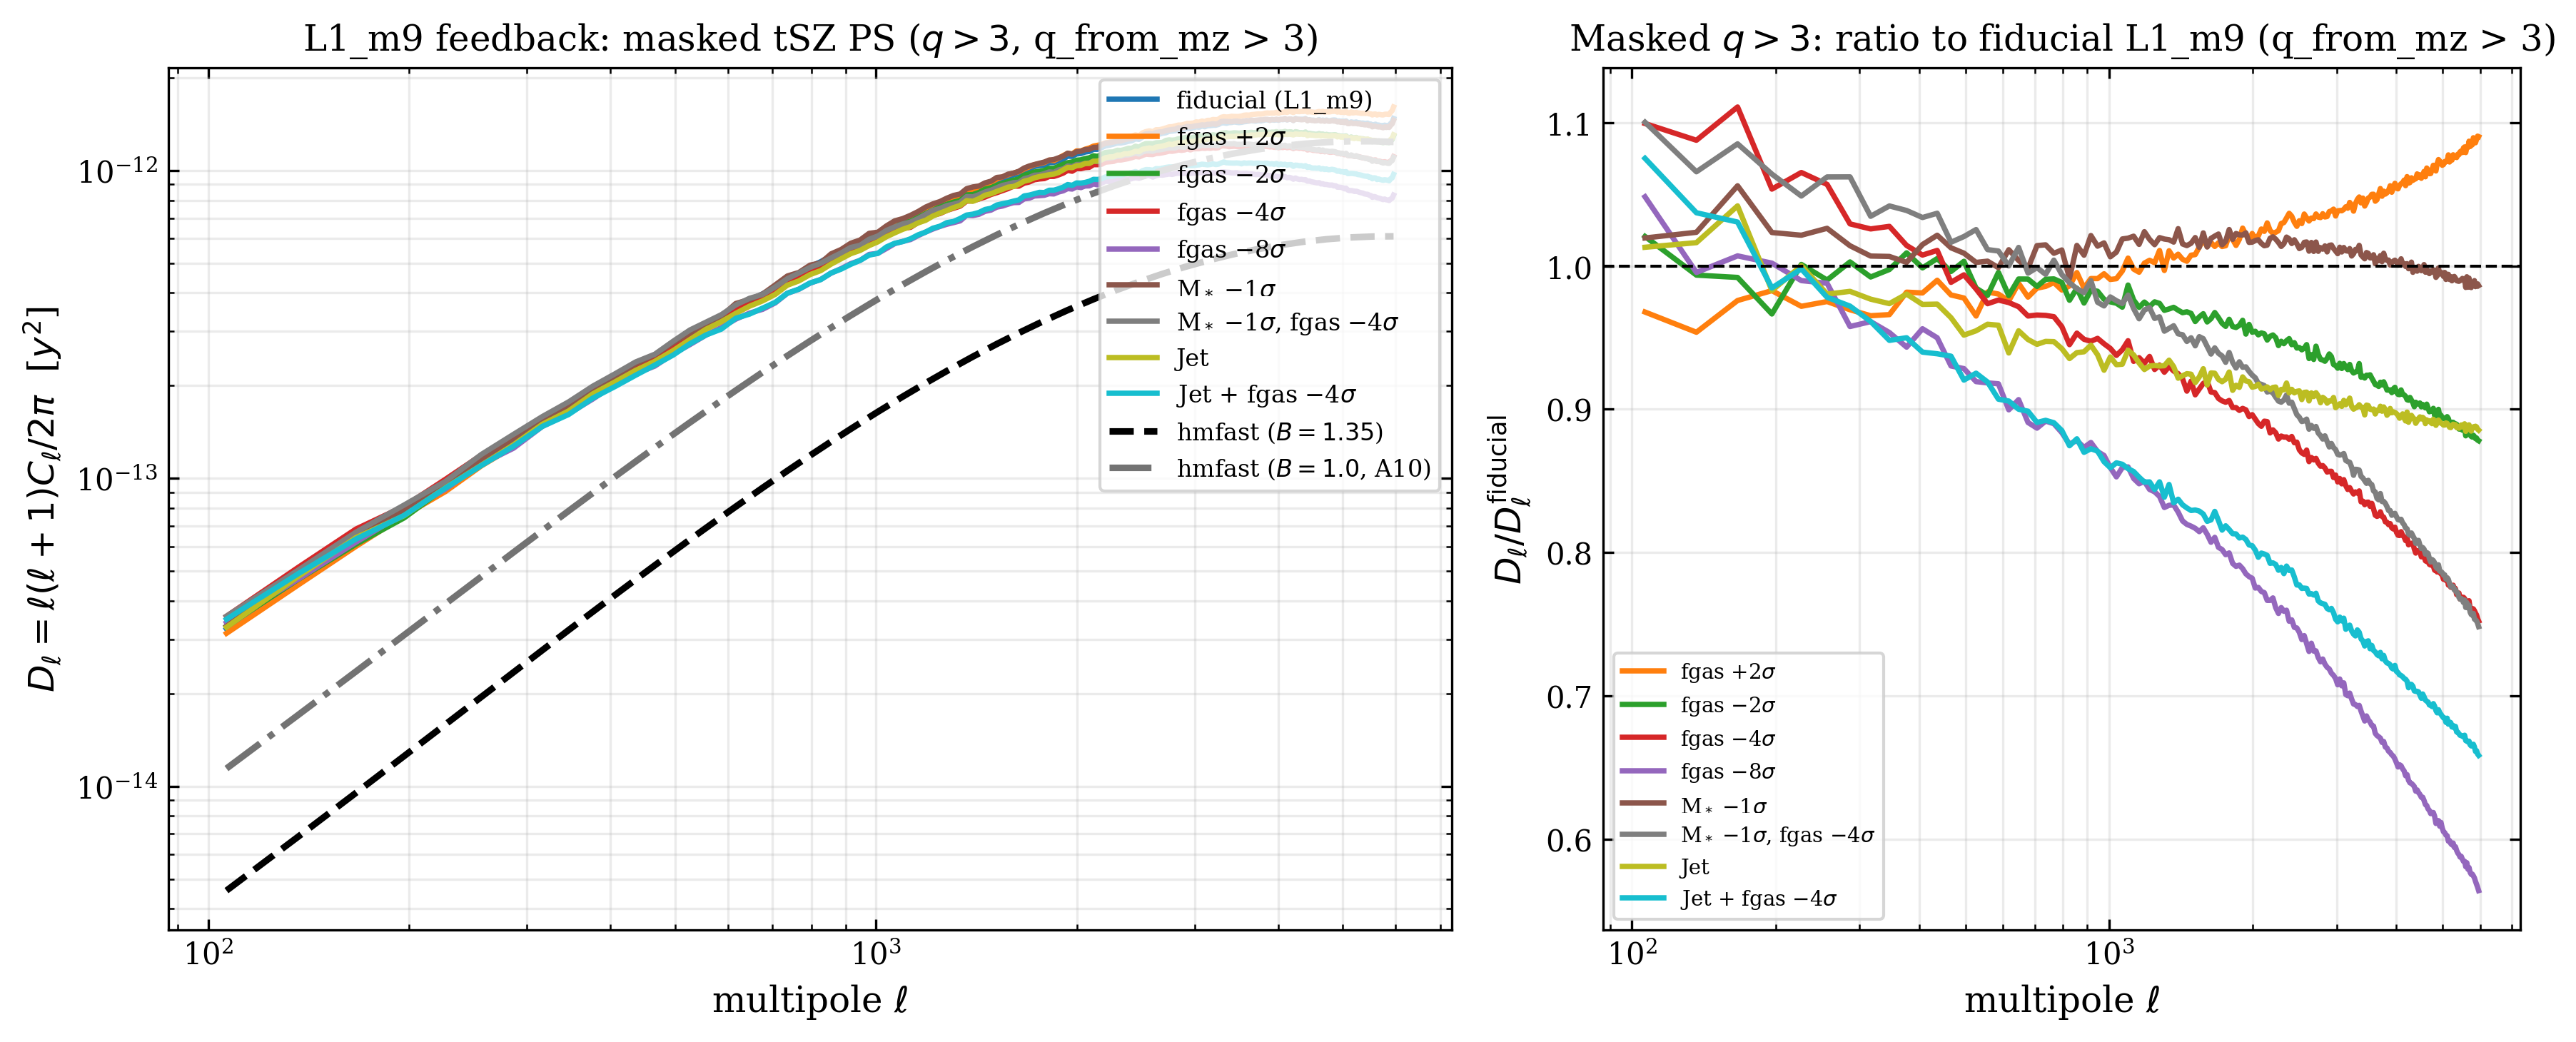

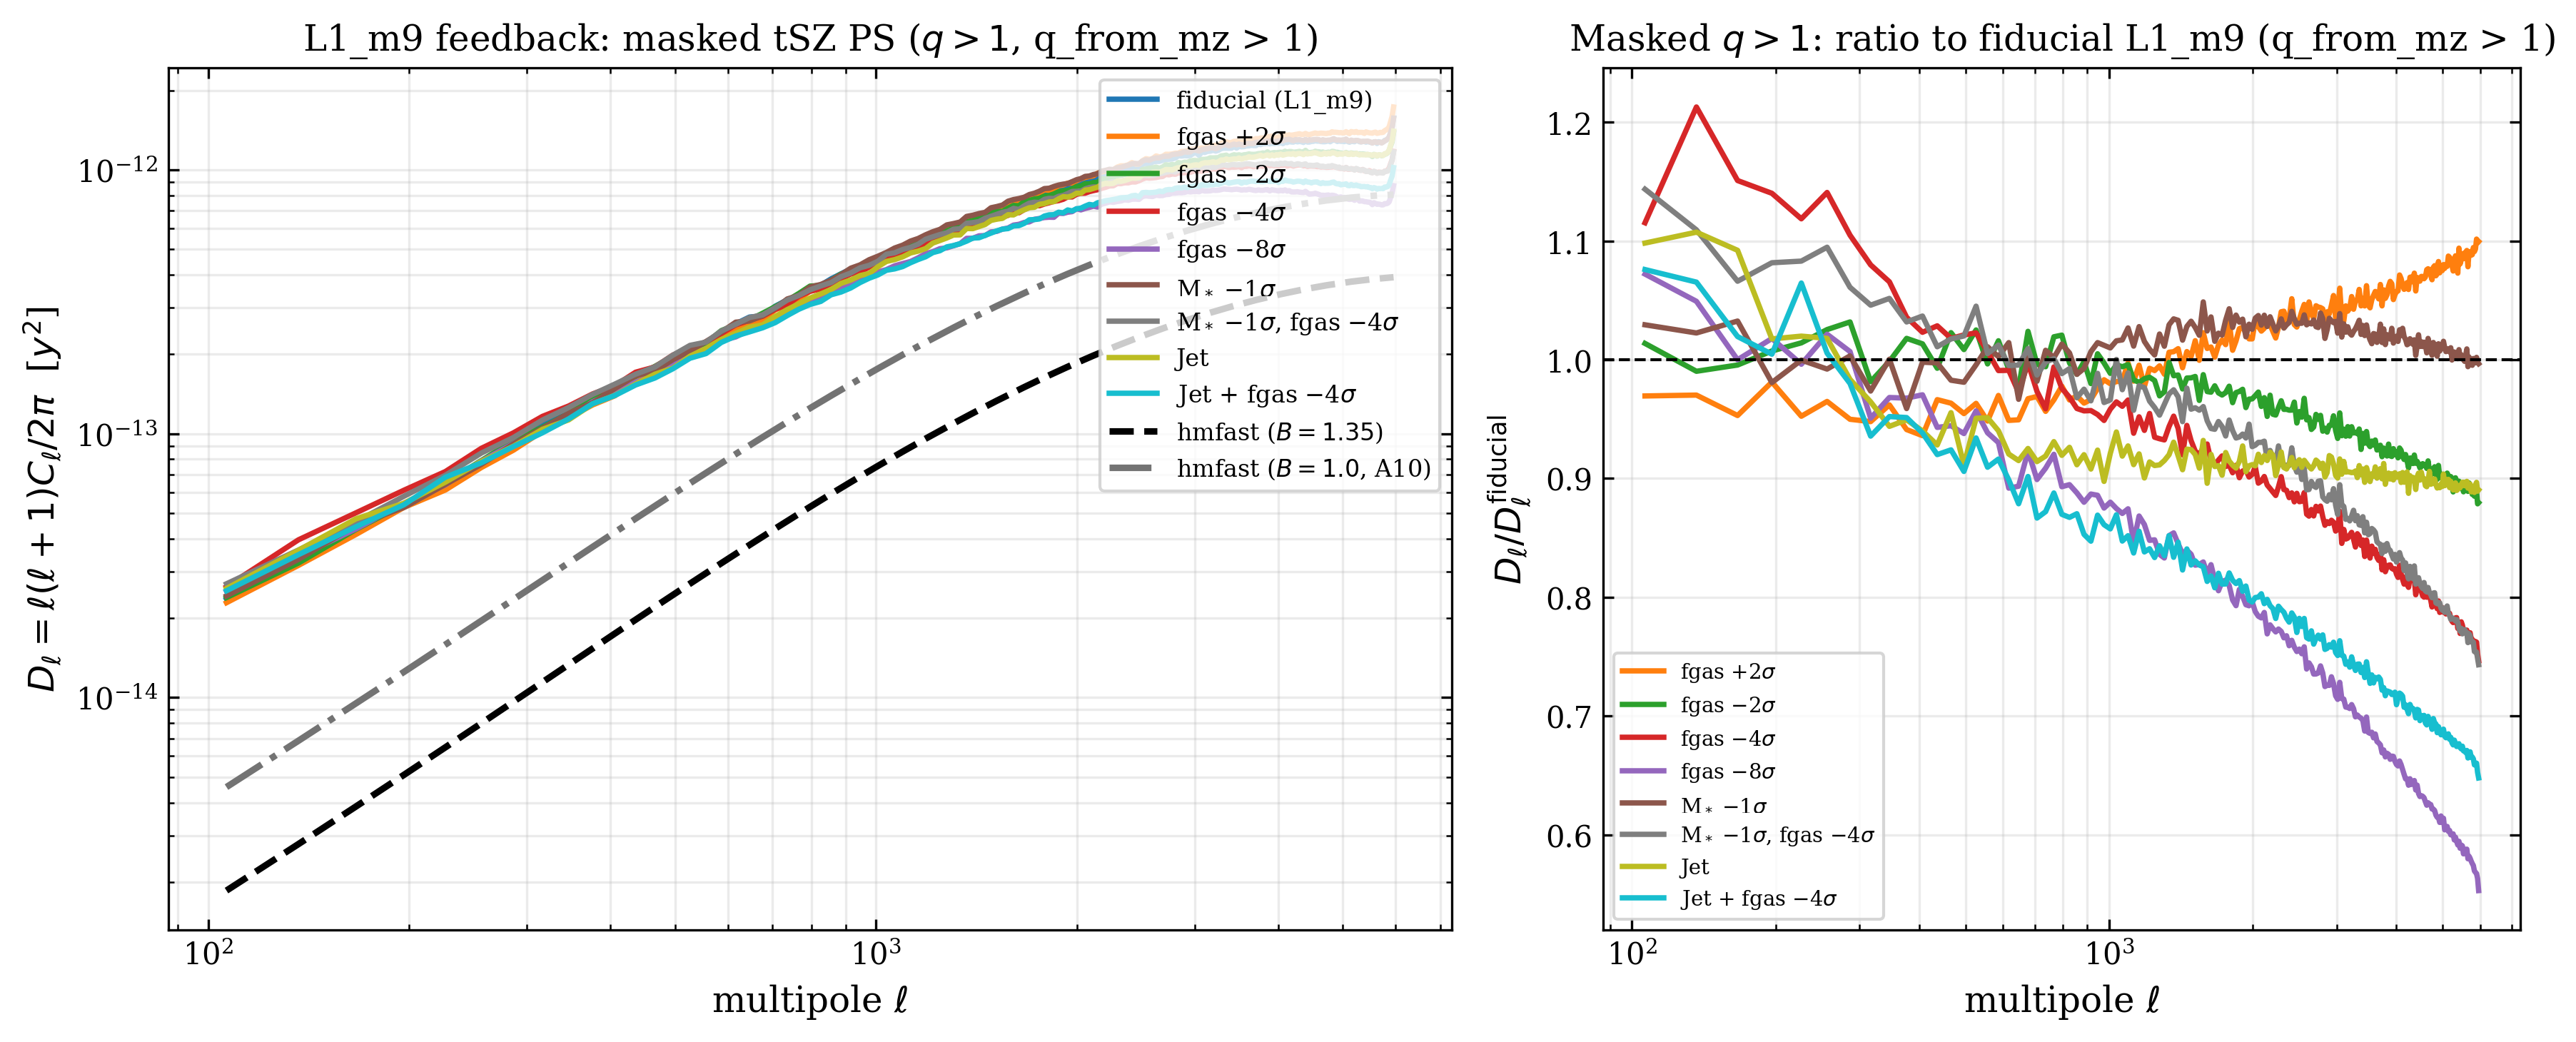

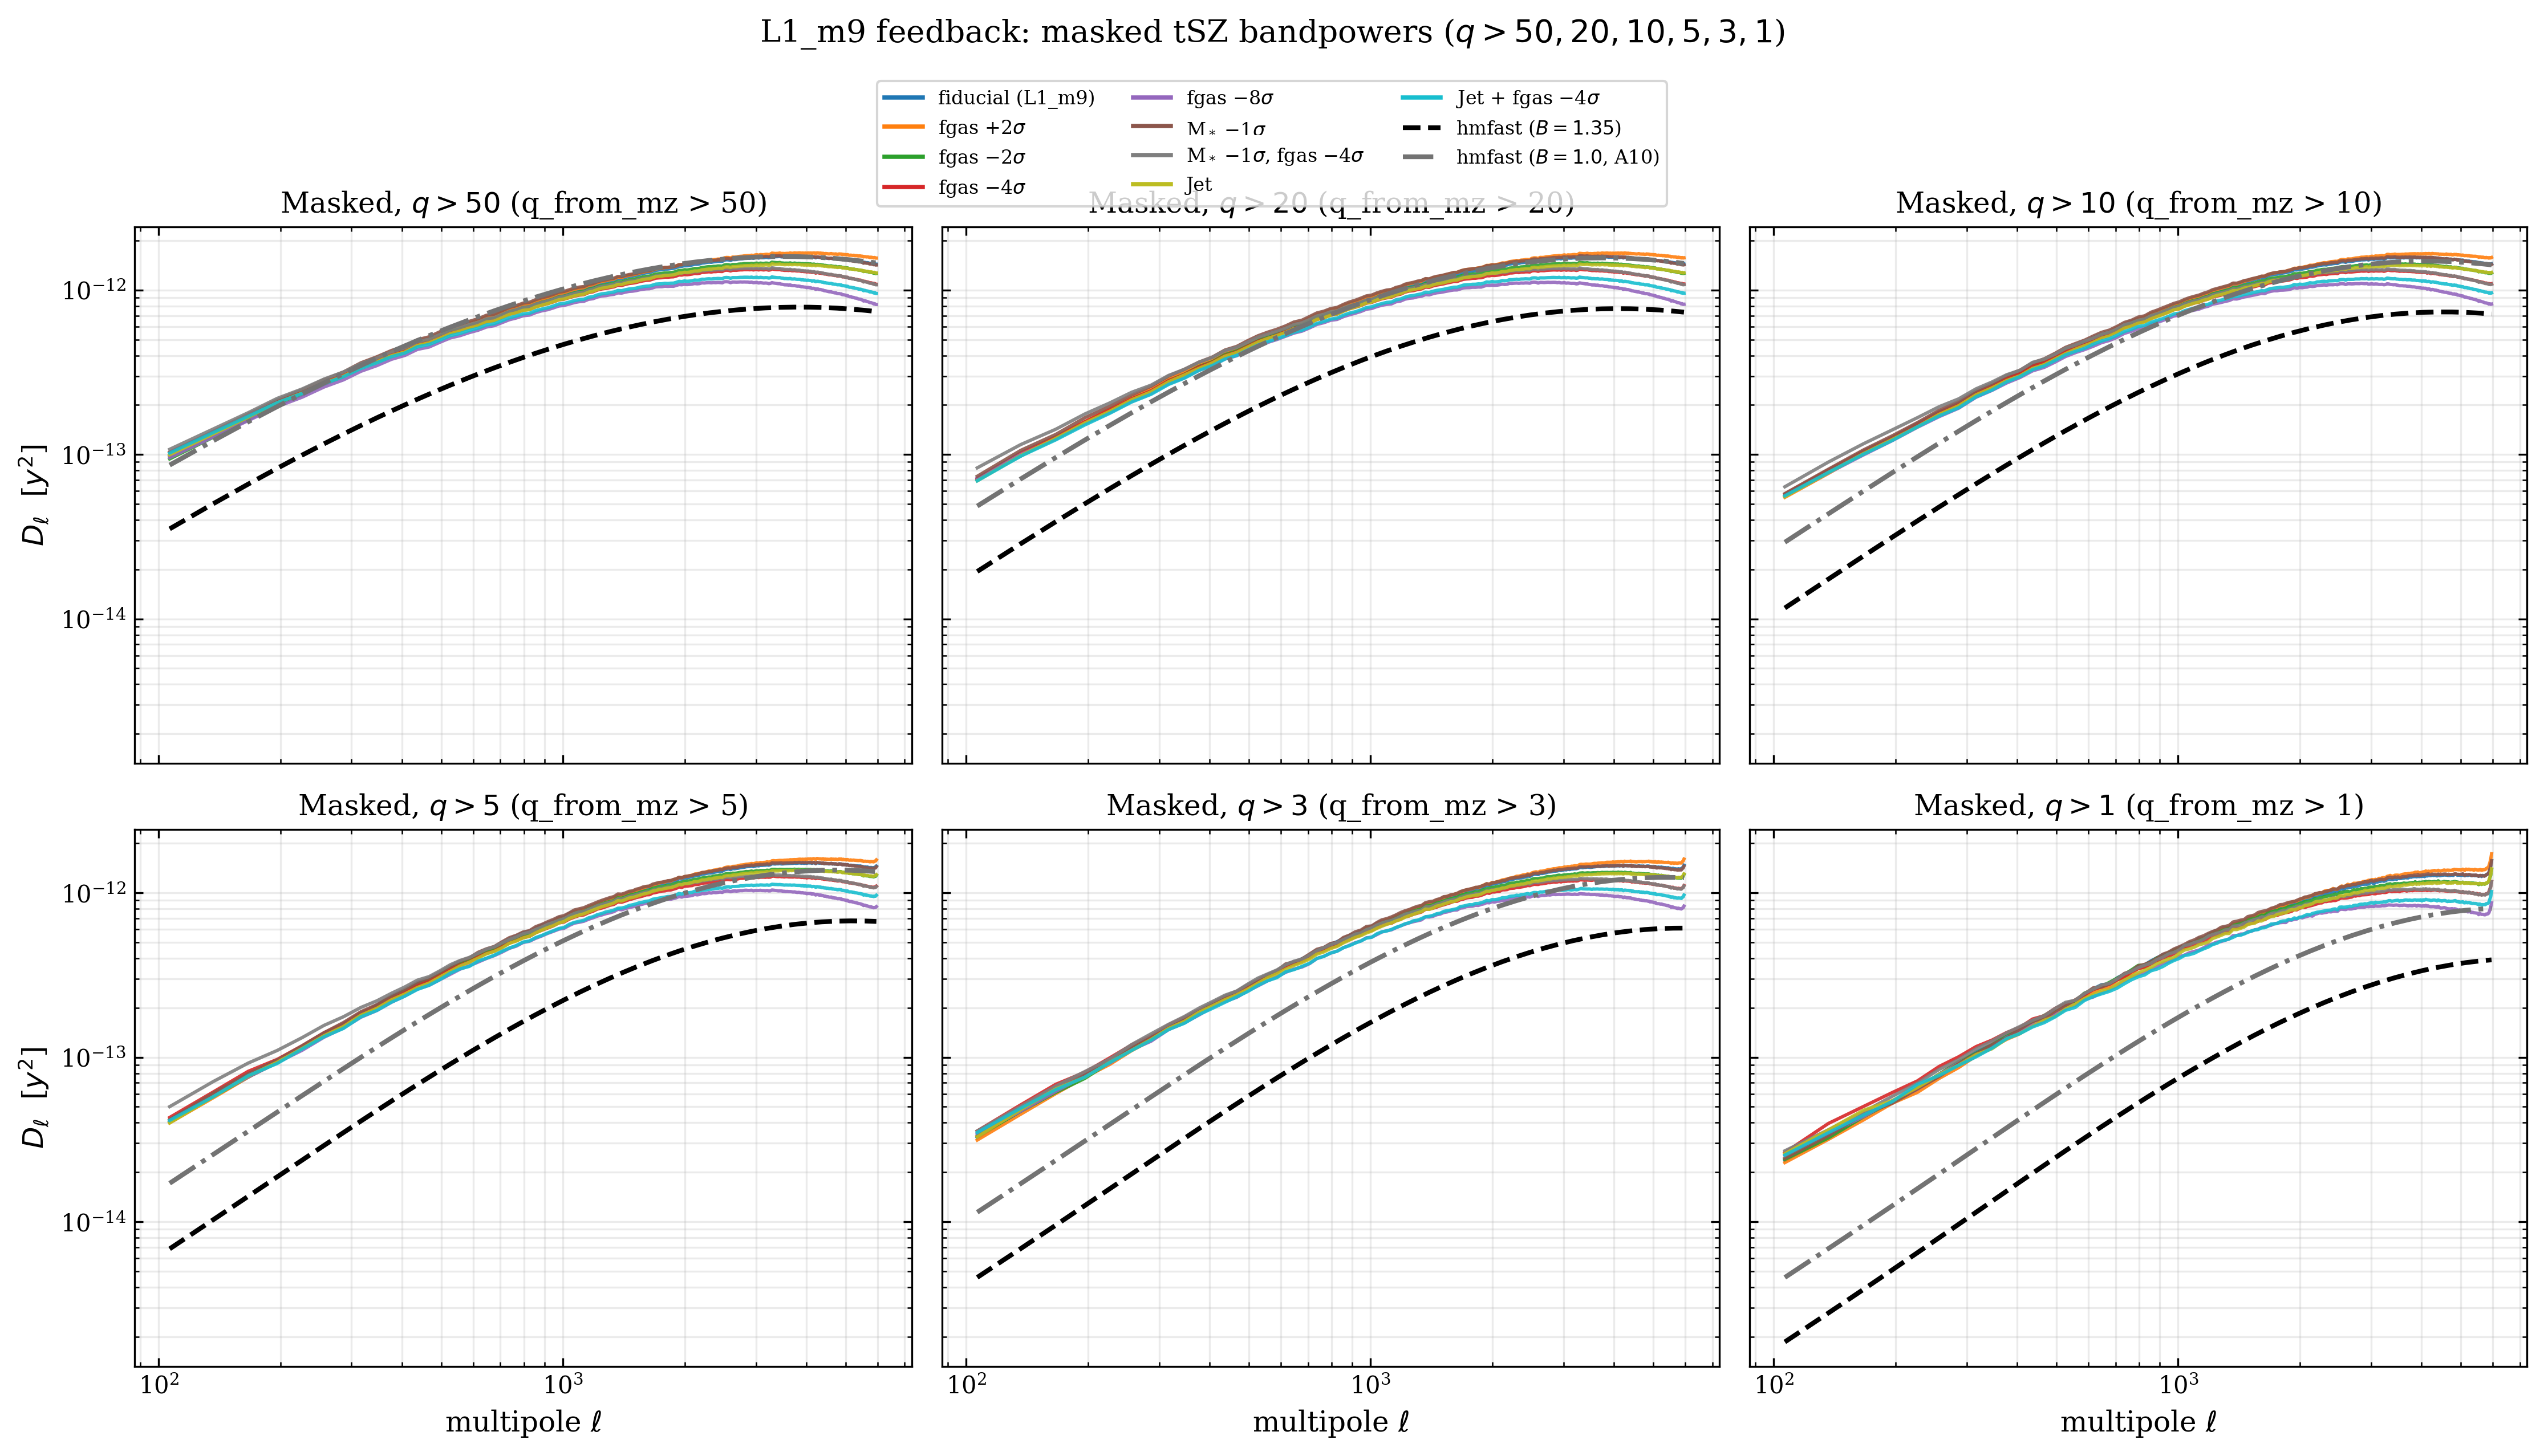

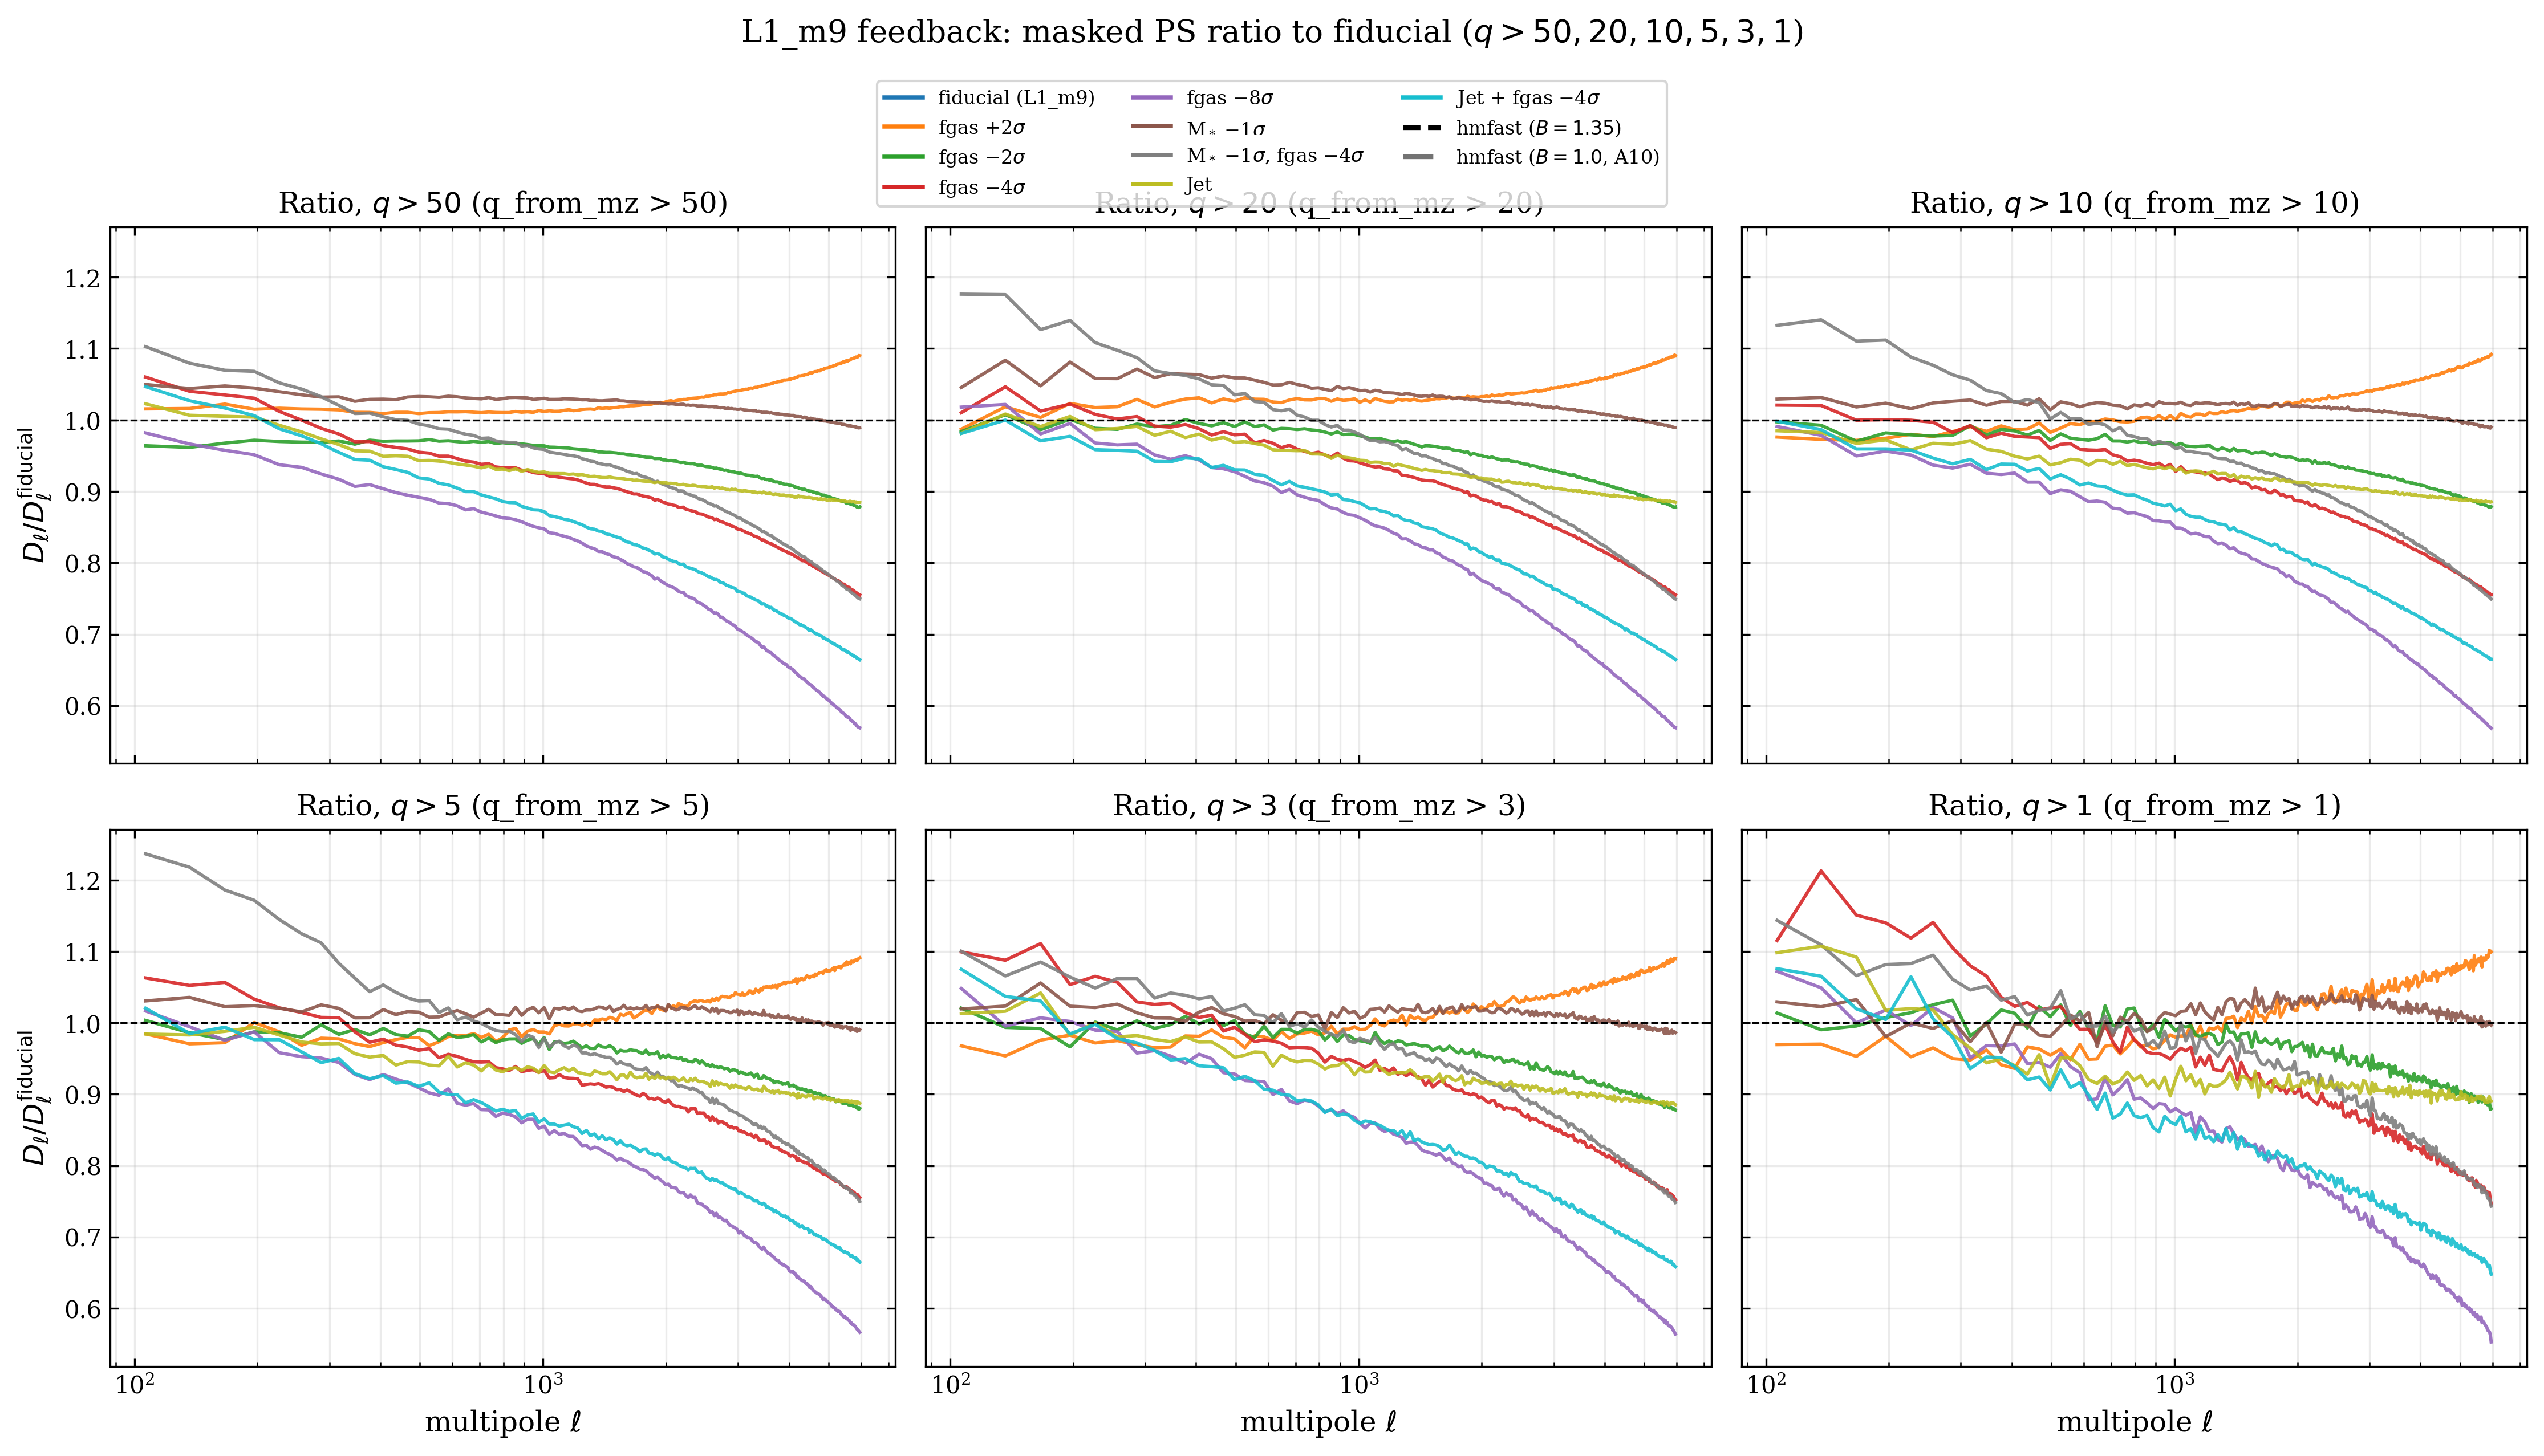

In [7]:
colors = plt.cm.tab10(np.linspace(0, 0.95, len(bp_variants)))
fid_idx = bp_variants.index("L1_m9")

for ic, tag, title in Q_CUTS:
    qval = int(q_cuts[ic])
    dl_fid_cut = dl_masked[fid_idx, ic, sel_nmt]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.4, 1]})

    ax = axes[0]
    for color, variant in zip(colors, bp_variants):
        iv = bp_variants.index(variant)
        ax.loglog(ell_nmt, dl_masked[iv, ic, sel_nmt], lw=1.8, color=color, label=LABELS.get(variant, variant))
    ax.loglog(ell_nmt, dl_th_masked[ic, sel_nmt], "k--", lw=2.2, label=TH_LABEL_B135)
    ax.loglog(ell_nmt, dl_th_masked_b1[ic, sel_nmt], color="0.45", ls="-.", lw=2.2, label=TH_LABEL_B1)
    ax.set_xlabel(r"multipole $\ell$")
    ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$  [$y^2$]")
    ax.set_title(f"L1_m9 feedback: masked tSZ PS ({title}, q_from_mz > {qval})")
    ax.legend(loc="upper right", fontsize=8, frameon=True)
    ax.grid(True, which="both", alpha=0.25)

    ax = axes[1]
    for color, variant in zip(colors, bp_variants):
        if variant == "L1_m9":
            continue
        iv = bp_variants.index(variant)
        ax.semilogx(ell_nmt, dl_masked[iv, ic, sel_nmt] / dl_fid_cut, lw=1.8, color=color, label=LABELS.get(variant, variant))
    ax.axhline(1.0, color="k", ls="--", lw=1)
    ax.set_xlabel(r"multipole $\ell$")
    ax.set_ylabel(r"$D_\ell / D_\ell^{\rm fiducial}$")
    ax.set_title(f"Masked {title}: ratio to fiducial L1_m9 (q_from_mz > {qval})")
    ax.legend(loc="best", fontsize=7, frameon=True)
    ax.grid(True, which="both", alpha=0.25)

    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"l1_feedback_masked_{tag}.{ext}")
    plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, (ic, tag, title) in zip(axes.ravel(), Q_CUTS):
    qval = int(q_cuts[ic])
    for color, variant in zip(colors, bp_variants):
        iv = bp_variants.index(variant)
        ax.loglog(ell_nmt, dl_masked[iv, ic, sel_nmt], lw=1.4, color=color, alpha=0.9)
    ax.loglog(ell_nmt, dl_th_masked[ic, sel_nmt], "k--", lw=2.0)
    ax.loglog(ell_nmt, dl_th_masked_b1[ic, sel_nmt], color="0.45", ls="-.", lw=2.0)
    ax.set_title(f"Masked, {title} (q_from_mz > {qval})")
    ax.grid(True, which="both", alpha=0.25)
for ax in axes[1]:
    ax.set_xlabel(r"multipole $\ell$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$D_\ell$  [$y^2$]")
handles = [
    plt.Line2D([0], [0], color=colors[i], lw=1.8, label=LABELS.get(bp_variants[i], bp_variants[i]))
    for i in range(len(bp_variants))
]
handles.append(plt.Line2D([0], [0], color="k", ls="--", lw=2, label=TH_LABEL_B135))
handles.append(plt.Line2D([0], [0], color="0.45", ls="-.", lw=2, label=TH_LABEL_B1))
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=8)
fig.suptitle(r"L1_m9 feedback: masked tSZ bandpowers ($q>50,20,10,5,3,1$)", y=1.06)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"l1_feedback_masked_4panel.{ext}", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, (ic, tag, title) in zip(axes.ravel(), Q_CUTS):
    qval = int(q_cuts[ic])
    dl_fid_cut = dl_masked[fid_idx, ic, sel_nmt]
    for color, variant in zip(colors, bp_variants):
        if variant == "L1_m9":
            continue
        iv = bp_variants.index(variant)
        ax.semilogx(ell_nmt, dl_masked[iv, ic, sel_nmt] / dl_fid_cut, lw=1.4, color=color, alpha=0.9)
    ax.axhline(1.0, color="k", ls="--", lw=0.8)
    ax.set_title(f"Ratio, {title} (q_from_mz > {qval})")
    ax.grid(True, which="both", alpha=0.25)
for ax in axes[1]:
    ax.set_xlabel(r"multipole $\ell$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$D_\ell / D_\ell^{\rm fiducial}$")
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=8)
fig.suptitle(r"L1_m9 feedback: masked PS ratio to fiducial ($q>50,20,10,5,3,1$)", y=1.06)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"l1_feedback_masked_ratio_4panel.{ext}", bbox_inches="tight")
plt.show()